In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

AUDIO_PATH     = '/content/drive/MyDrive/Task 1/D1/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files'
LABELED_CSV    = '/content/drive/MyDrive/Task 1/D1/Respiratory_Sound_Database/Respiratory_Sound_Database/labeled_files.csv'
RESULTS_DIR    = '/content/drive/MyDrive/Task2_Results'
PROCESSED_DIR  = '/content/drive/MyDrive/Task2_Processed'

os.makedirs(RESULTS_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Audio path exists   :", os.path.exists(AUDIO_PATH))
print("CSV path exists     :", os.path.exists(LABELED_CSV))

wav_files = [f for f in os.listdir(AUDIO_PATH) if f.endswith('.wav')]
print(f"Total wav files     : {len(wav_files)}")

Audio path exists   : True
CSV path exists     : True
Total wav files     : 920


In [ ]:
import gc
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa
import cv2
from tqdm import tqdm

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization,
    LeakyReLU, MaxPool2D, GlobalAveragePooling2D,
    Dropout, Dense, Multiply, Concatenate
)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report
)

print("Libraries loaded")
print("TF version:", tf.__version__)

Libraries loaded
TF version: 2.20.0


In [ ]:
task2_classes = [
    'Bronchiectasis',
    'Bronchiolitis',
    'COPD',
    'Healthy',
    'Pneumonia',
    'URTI'
]

df = pd.read_csv(LABELED_CSV)

# Keep wav files only, Task 2 classes only
df_wav = df[
    (df['filename'].str.endswith('.wav')) &
    (df['diagnosis'].isin(task2_classes))
].reset_index(drop=True)

print(f"Task 2 wav files: {len(df_wav)}")
print("\nClass distribution:")
print(df_wav['diagnosis'].value_counts())

# Build filename → label map
file_to_label = dict(zip(df_wav['filename'], df_wav['diagnosis']))

Task 2 wav files: 917

Class distribution:
diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
Name: count, dtype: int64


In [ ]:
def process_audio_to_images(wav_path, sr_target=4000):
    """
    Paper pipeline (Section III-A and III-C):
    1. Resample to 4 kHz
    2. 5-sec snippets, 50% overlap
    3. DFT-based baseline wander removal (0–1 Hz)
    4. Amplitude normalization [–1, 1]
    5. Mel spectrogram: 64 filters, 1024 FFT, 512 hop, Hamming window
    6. Log scale → resize to 64×38 → jet colormap → float32
    """
    images = []
    try:
        signal, _ = librosa.load(wav_path, sr=sr_target, mono=True)
    except Exception as e:
        print(f"  Error loading {wav_path}: {e}")
        return images

    win = 5 * sr_target    # 20000 samples
    hop = win // 2         # 50% overlap = 10000 samples

    for start in range(0, len(signal) - win + 1, hop):
        snippet = signal[start: start + win].copy()

        # DFT baseline wander removal
        N       = len(snippet)
        fft_val = np.fft.fft(snippet)
        freqs   = np.fft.fftfreq(N, 1.0 / sr_target)
        fft_val[np.abs(freqs) <= 1.0] = 0
        snippet = np.real(np.fft.ifft(fft_val))

        # Amplitude normalization
        max_val = np.max(np.abs(snippet))
        if max_val > 0:
            snippet = snippet / max_val

        # Mel spectrogram
        mel    = librosa.feature.melspectrogram(
            y=snippet, sr=sr_target,
            n_fft=1024, hop_length=512,
            n_mels=64, window='hamming'
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Resize → jet colormap → float32
        mel_resized = cv2.resize(mel_db, (38, 64))
        mel_norm    = cv2.normalize(
            mel_resized, None, 0, 255, cv2.NORM_MINMAX
        ).astype(np.uint8)
        mel_jet = cv2.applyColorMap(mel_norm, cv2.COLORMAP_JET)
        mel_rgb = cv2.cvtColor(mel_jet, cv2.COLOR_BGR2RGB)

        images.append(mel_rgb.astype('float32') / 255.0)

    return images

print("Audio processing function defined")

Audio processing function defined


In [ ]:
X_list = []
y_list = []
skipped = 0

print(f"Processing {len(df_wav)} wav files...")

for _, row in tqdm(df_wav.iterrows(), total=len(df_wav), desc="Processing"):
    wav_path = os.path.join(AUDIO_PATH, row['filename'])

    if not os.path.exists(wav_path):
        skipped += 1
        continue

    images = process_audio_to_images(wav_path)
    for img in images:
        X_list.append(img)
        y_list.append(row['diagnosis'])

print(f"\nSkipped (file not found): {skipped}")
print(f"Total snippets generated: {len(X_list)}")

X     = np.array(X_list, dtype='float32')
y_raw = np.array(y_list)

print("\nDataset shape:", X.shape)
print("\nClass distribution:")
unique, counts = np.unique(y_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u:20s}: {c}")

Processing 917 wav files...


Processing: 100%|██████████| 917/917 [04:17<00:00,  3.57it/s]


Skipped (file not found): 0
Total snippets generated: 6916

Dataset shape: (6916, 64, 38, 3)

Class distribution:
  Bronchiectasis      : 112
  Bronchiolitis       : 91
  COPD                : 6055
  Healthy             : 240
  Pneumonia           : 259
  URTI                : 159


In [ ]:
label_to_idx = {cls: idx for idx, cls in enumerate(task2_classes)}
y_labels     = np.array([label_to_idx[l] for l in y_raw])
Y            = np.eye(len(task2_classes))[y_labels]

print("Shapes — X:", X.shape, "| Y:", Y.shape, "| y_labels:", y_labels.shape)
print("\nFinal class mapping:")
for idx, cls in enumerate(task2_classes):
    print(f"  {idx} = {cls:20s}: {(y_labels==idx).sum()} snippets")

# Save so you never need to re-process audio again
np.save(f'{PROCESSED_DIR}/X_task2.npy',        X)
np.save(f'{PROCESSED_DIR}/Y_onehot_task2.npy', Y)
np.save(f'{PROCESSED_DIR}/y_labels_task2.npy', y_labels)
print("\nSaved to Drive — you can reload these next time instead of reprocessing.")

Shapes — X: (6916, 64, 38, 3) | Y: (6916, 6) | y_labels: (6916,)

Final class mapping:
  0 = Bronchiectasis      : 112 snippets
  1 = Bronchiolitis       : 91 snippets
  2 = COPD                : 6055 snippets
  3 = Healthy             : 240 snippets
  4 = Pneumonia           : 259 snippets
  5 = URTI                : 159 snippets

Saved to Drive — you can reload these next time instead of reprocessing.


In [ ]:
# ---- SKIP THIS CELL on first run ----
# ---- On future runs: run Cell 1→4, then THIS cell, then Cell 8 onwards ----

X        = np.load(f'{PROCESSED_DIR}/X_task2.npy')
Y        = np.load(f'{PROCESSED_DIR}/Y_onehot_task2.npy')
y_labels = np.load(f'{PROCESSED_DIR}/y_labels_task2.npy')

print("Reloaded — X:", X.shape, "Y:", Y.shape)
for idx, cls in enumerate(task2_classes):
    print(f"  {idx} = {cls}: {(y_labels==idx).sum()}")

Reloaded — X: (6916, 64, 38, 3) Y: (6916, 6)
  0 = Bronchiectasis: 112
  1 = Bronchiolitis: 91
  2 = COPD: 6055
  3 = Healthy: 240
  4 = Pneumonia: 259
  5 = URTI: 159


In [ ]:
def augment_spectrogram(img):
    aug = []
    H, W, C = img.shape

    # Time stretch: 4 factors
    for factor in [0.8, 0.9, 1.1, 1.2]:
        stretched = np.zeros((H, W, C), dtype='float32')
        new_len   = max(1, int(W * factor))
        x_new     = np.linspace(0, W - 1, new_len)
        x_old     = np.arange(W)
        for c in range(C):
            for row in range(H):
                interped = np.interp(x_new, x_old, img[row, :, c])
                if new_len < W:
                    interped = np.pad(interped, (0, W - new_len), mode='edge')
                else:
                    interped = interped[:W]
                stretched[row, :, c] = interped
        aug.append(stretched)

    # Noise addition: 3 levels
    for noise_std in [0.03, 0.06, 0.10]:
        noisy = img + np.random.normal(0, noise_std, img.shape).astype('float32')
        aug.append(np.clip(noisy, 0.0, 1.0))

    # Frequency masking
    masked  = img.copy()
    f_start = np.random.randint(0, H - 16)
    masked[f_start:f_start+16, :, :] = 0
    aug.append(masked)

    # Time masking
    tmasked = img.copy()
    t_start = np.random.randint(0, W - 10)
    tmasked[:, t_start:t_start+10, :] = 0
    aug.append(tmasked)

    # Brightness shift
    aug.append(np.clip(
        img * np.random.uniform(0.85, 1.15), 0.0, 1.0
    ).astype('float32'))

    return aug  # 10 versions per sample

# Augment all minority classes to 6000
target_count = 6000
X_aug_list   = [X]
Y_aug_list   = [Y]

for cls_idx in range(len(task2_classes)):
    current = (y_labels == cls_idx).sum()
    if current >= target_count:
        print(f"Class {cls_idx} ({task2_classes[cls_idx]:20s}): {current} — skipping")
        continue

    X_min  = X[y_labels == cls_idx]
    Y_min  = Y[y_labels == cls_idx]
    needed = target_count - current
    added  = 0
    i      = 0

    while added < needed:
        for aug_img in augment_spectrogram(X_min[i % len(X_min)]):
            if added >= needed:
                break
            X_aug_list.append(aug_img[np.newaxis])
            Y_aug_list.append(Y_min[i % len(Y_min)][np.newaxis])
            added += 1
        i += 1

    print(f"Class {cls_idx} ({task2_classes[cls_idx]:20s}): {current} → {current + added}")

X        = np.concatenate(X_aug_list, axis=0)
Y        = np.concatenate(Y_aug_list, axis=0)
y_labels = np.argmax(Y, axis=1)

print(f"\nFinal augmented shape: {X.shape}")
for i, cls in enumerate(task2_classes):
    print(f"  {i} = {cls:20s}: {(y_labels==i).sum()}")

Class 0 (Bronchiectasis      ): 112 → 6000
Class 1 (Bronchiolitis       ): 91 → 6000
Class 2 (COPD                ): 6055 — skipping
Class 3 (Healthy             ): 240 → 6000
Class 4 (Pneumonia           ): 259 → 6000
Class 5 (URTI                ): 159 → 6000

Final augmented shape: (36055, 64, 38, 3)
  0 = Bronchiectasis      : 6000
  1 = Bronchiolitis       : 6000
  2 = COPD                : 6055
  3 = Healthy             : 6000
  4 = Pneumonia           : 6000
  5 = URTI                : 6000


In [ ]:
def RDLINet(dim, output_neurons, output_activation):

    def block(x, filters, reps):
        for _ in range(reps):
            t1 = Conv2D(filters[0], (1,1), padding='same')(x)
            t1 = BatchNormalization()(t1)
            t1 = LeakyReLU()(t1)

            t2 = DepthwiseConv2D((3,3), padding='same')(x)
            t2 = BatchNormalization()(t2)
            t2 = LeakyReLU()(t2)
            t2 = Conv2D(filters[1], (1,1), padding='same')(t2)
            t2 = BatchNormalization()(t2)
            t2 = LeakyReLU()(t2)

            t3 = DepthwiseConv2D((5,5), padding='same')(x)
            t3 = BatchNormalization()(t3)
            t3 = LeakyReLU()(t3)
            t3 = Conv2D(filters[2], (1,1), padding='same')(t3)
            t3 = BatchNormalization()(t3)
            t3 = LeakyReLU()(t3)

            t4 = MaxPool2D((3,3), strides=1, padding='same')(x)
            t4 = Conv2D(filters[3], (1,1), padding='same')(t4)
            t4 = BatchNormalization()(t4)
            t4 = LeakyReLU()(t4)

            x  = Concatenate()([t1, t2, t3, t4])
        return x

    input_layer = Input(shape=dim)
    k = 32

    x = Conv2D(k, (3,3), strides=2, padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = MaxPool2D((3,3), strides=2, padding='same')(x)

    x = DepthwiseConv2D((3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Conv2D(2*k, (1,1), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = MaxPool2D((2,2))(x)

    x = block(x, [k, k, k, k], 2)
    x = MaxPool2D((2,2))(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)

    t1 = Dense(15, 'sigmoid')(x)
    t2 = Dense(15, 'linear')(x)
    t3 = Multiply()([t1, t2])

    output = Dense(output_neurons, output_activation)(t3)
    return Model(input_layer, output)

print("Model defined")

Model defined


Input shape: (64, 38, 3)

FOLD 1
Epoch 1/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7351 - loss: 0.6705 - val_accuracy: 0.1764 - val_loss: 7.4684 - learning_rate: 0.0080
Epoch 2/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9266 - loss: 0.2007 - val_accuracy: 0.6321 - val_loss: 1.5577 - learning_rate: 0.0080
Epoch 3/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9589 - loss: 0.1185 - val_accuracy: 0.3764 - val_loss: 7.9869 - learning_rate: 0.0080
Epoch 4/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9739 - loss: 0.0797 - val_accuracy: 0.5171 - val_loss: 3.6951 - learning_rate: 0.0080
Epoch 5/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9766 - loss: 0.0689 - val_accuracy: 0.2574 - val_loss: 9.6299 - learning_rate: 0.0080
Epoch 6/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9818 - loss: 0.0531 - val_accuracy: 0.7518 - val_loss: 1.2630 - learning_rate: 0.0080
Epoch 7/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3

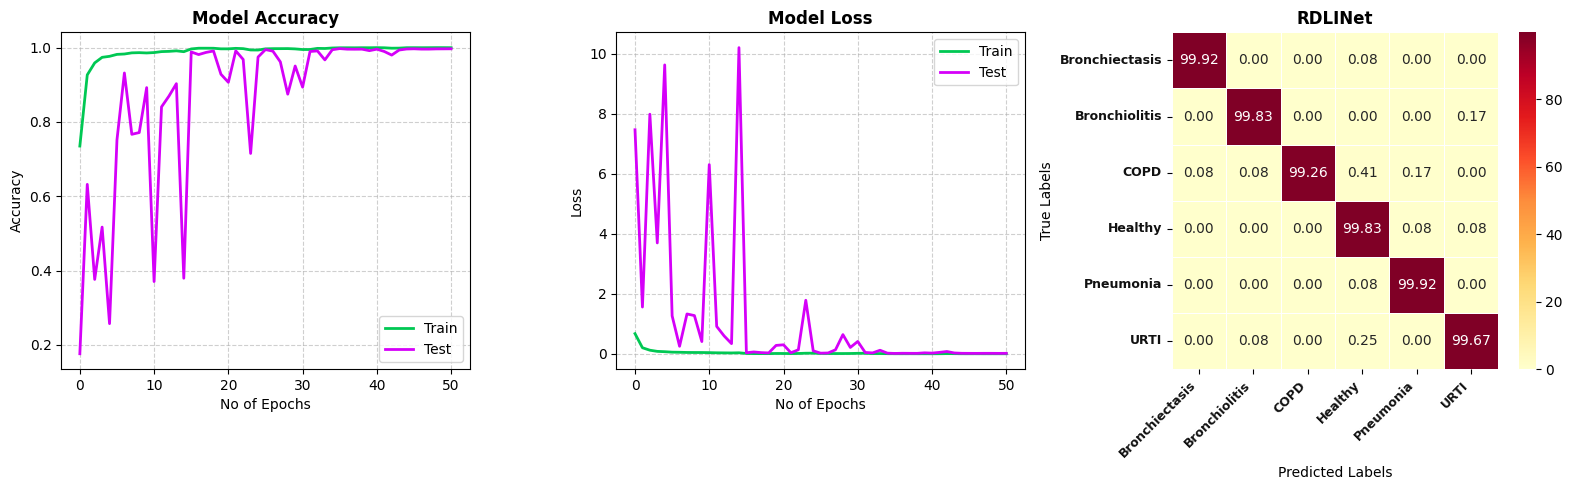

Fold 1 weights saved.

FOLD 2
Epoch 1/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.7312 - loss: 0.6820 - val_accuracy: 0.1718 - val_loss: 6.4567 - learning_rate: 0.0080
Epoch 2/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9300 - loss: 0.1957 - val_accuracy: 0.3215 - val_loss: 6.1238 - learning_rate: 0.0080
Epoch 3/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9623 - loss: 0.1089 - val_accuracy: 0.2423 - val_loss: 16.2175 - learning_rate: 0.0080
Epoch 4/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9712 - loss: 0.0813 - val_accuracy: 0.3686 - val_loss: 6.9346 - learning_rate: 0.0080
Epoch 5/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9771 - loss: 0.0683 - val_accuracy: 0.8267 - val_loss: 0.6467 - learning_rate: 0.0080
Epoch 6/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9810 - loss: 0.0553 - val_accuracy: 0.8437 - val_loss: 0.7803 - learning_rate: 0.0080
Epoch 7/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 

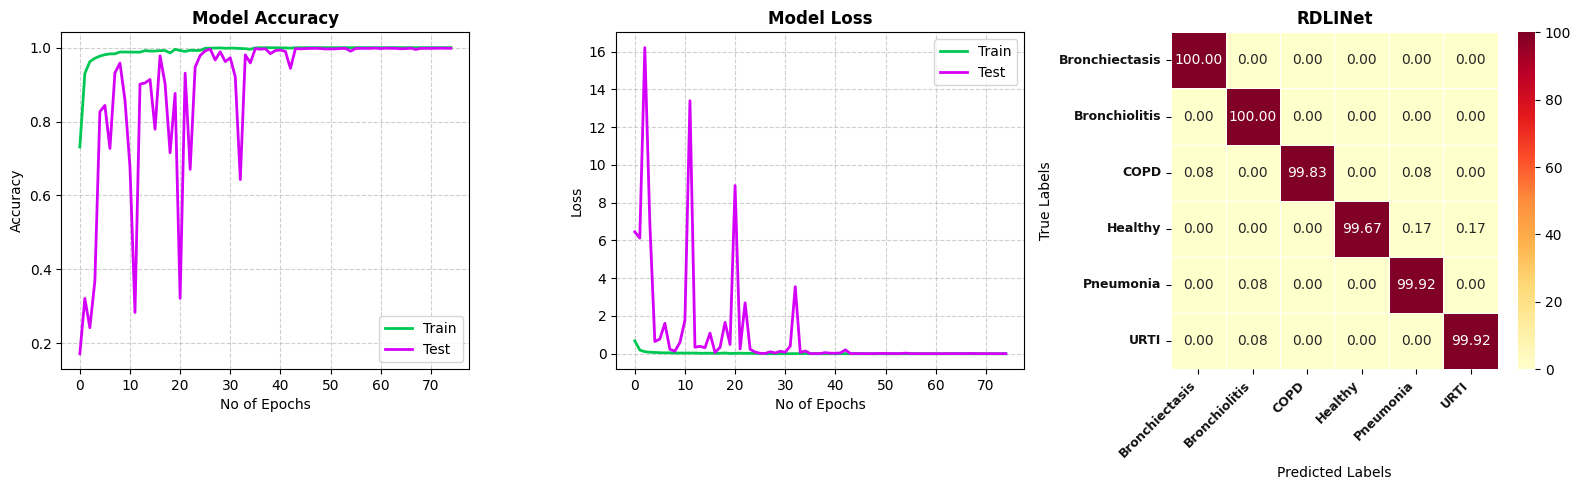

Fold 2 weights saved.

FOLD 3
Epoch 1/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.7264 - loss: 0.6944 - val_accuracy: 0.1914 - val_loss: 5.6223 - learning_rate: 0.0080
Epoch 2/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9240 - loss: 0.2110 - val_accuracy: 0.7050 - val_loss: 1.5237 - learning_rate: 0.0080
Epoch 3/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9591 - loss: 0.1161 - val_accuracy: 0.6566 - val_loss: 1.7232 - learning_rate: 0.0080
Epoch 4/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9701 - loss: 0.0862 - val_accuracy: 0.8336 - val_loss: 0.8335 - learning_rate: 0.0080
Epoch 5/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9784 - loss: 0.0608 - val_accuracy: 0.6098 - val_loss: 2.6427 - learning_rate: 0.0080
Epoch 6/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9793 - loss: 0.0611 - val_accuracy: 0.9476 - val_loss: 0.1577 - learning_rate: 0.0080
Epoch 7/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 1

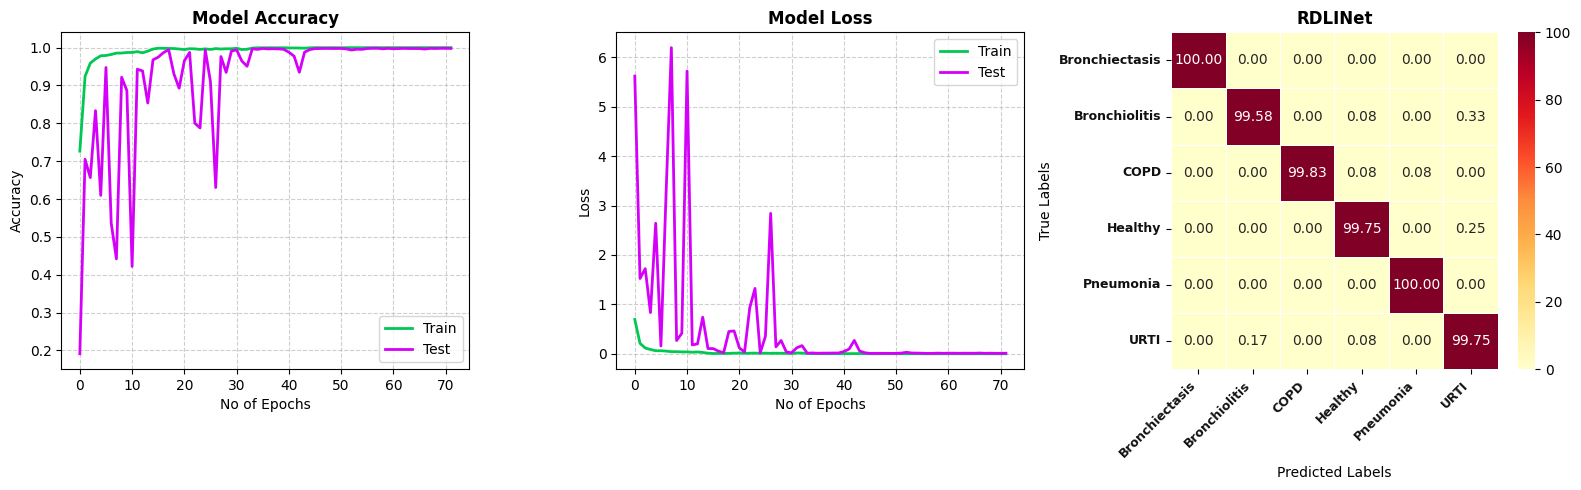

Fold 3 weights saved.

FOLD 4
Epoch 1/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.7061 - loss: 0.7336 - val_accuracy: 0.1804 - val_loss: 4.0004 - learning_rate: 0.0080
Epoch 2/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9279 - loss: 0.2038 - val_accuracy: 0.8100 - val_loss: 0.6815 - learning_rate: 0.0080
Epoch 3/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9616 - loss: 0.1141 - val_accuracy: 0.8228 - val_loss: 0.6440 - learning_rate: 0.0080
Epoch 4/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9722 - loss: 0.0801 - val_accuracy: 0.7186 - val_loss: 1.1913 - learning_rate: 0.0080
Epoch 5/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9806 - loss: 0.0565 - val_accuracy: 0.9233 - val_loss: 0.2304 - learning_rate: 0.0080
Epoch 6/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9790 - loss: 0.0614 - val_accuracy: 0.9248 - val_loss: 0.2311 - learning_rate: 0.0080
Epoch 7/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 

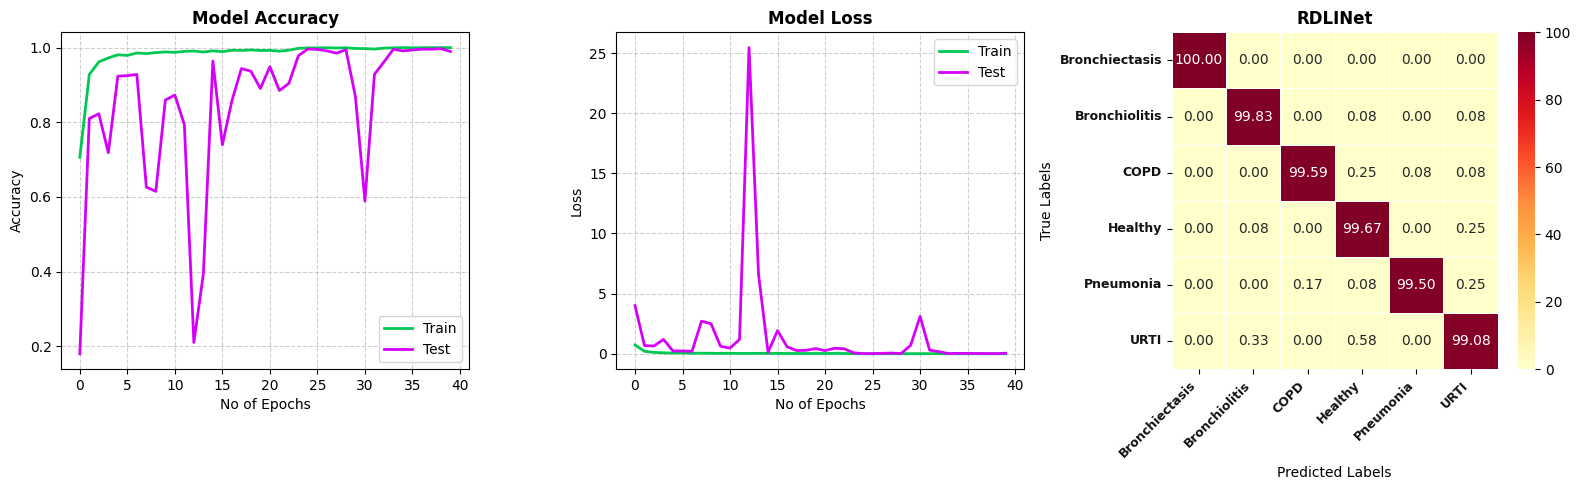

Fold 4 weights saved.

FOLD 5
Epoch 1/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.7044 - loss: 0.7392 - val_accuracy: 0.1704 - val_loss: 6.8714 - learning_rate: 0.0080
Epoch 2/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9226 - loss: 0.2133 - val_accuracy: 0.4945 - val_loss: 3.0258 - learning_rate: 0.0080
Epoch 3/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9610 - loss: 0.1134 - val_accuracy: 0.9461 - val_loss: 0.1650 - learning_rate: 0.0080
Epoch 4/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9727 - loss: 0.0789 - val_accuracy: 0.2749 - val_loss: 10.1285 - learning_rate: 0.0080
Epoch 5/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9781 - loss: 0.0634 - val_accuracy: 0.3011 - val_loss: 13.3558 - learning_rate: 0.0080
Epoch 6/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9788 - loss: 0.0629 - val_accuracy: 0.7096 - val_loss: 1.2445 - learning_rate: 0.0080
Epoch 7/300
226/226 ━━━━━━━━━━━━━━━━━━━━ 3

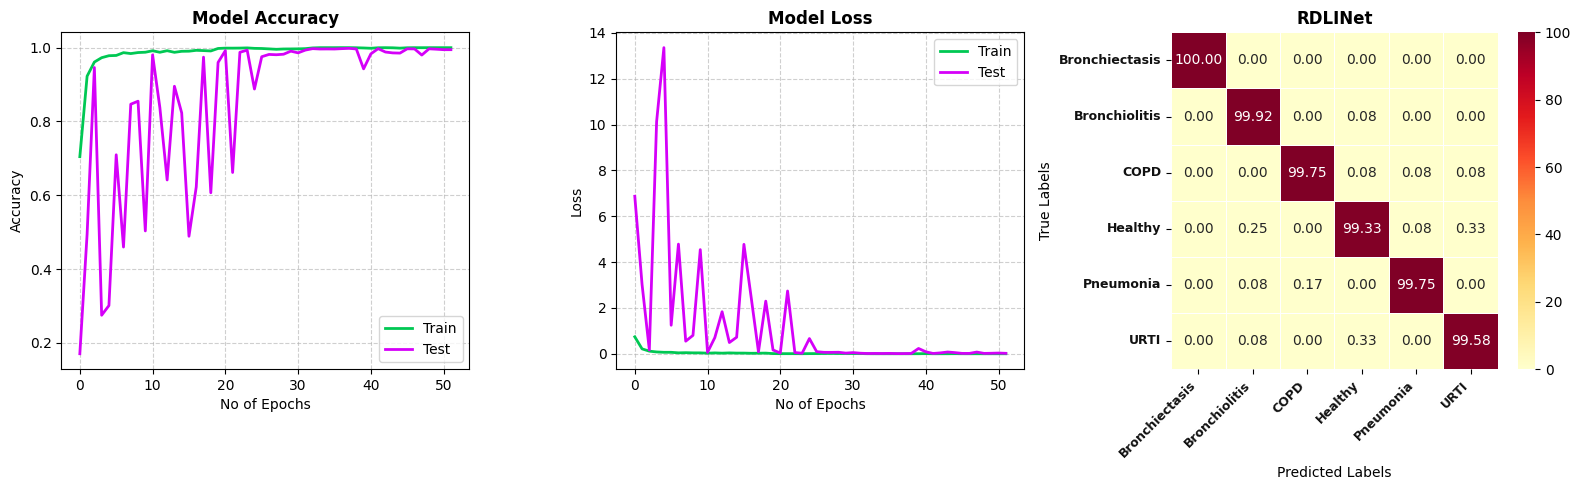

Fold 5 weights saved.

FINAL RESULTS — TASK 2 (D1 only)
Fold 1 Accuracy : 99.7365%
Fold 2 Accuracy : 99.8891%
Fold 3 Accuracy : 99.8197%
Fold 4 Accuracy : 99.6117%
Fold 5 Accuracy : 99.7226%

Mean Accuracy  : 99.7559%
Std Deviation  : 0.0939%
Paper Target   : 99.6%


In [ ]:
# ── Combined Figure: Accuracy + Loss + Confusion Matrix ──────────────────────
H, W, C = X.shape[1], X.shape[2], X.shape[3]
print(f"Input shape: ({H}, {W}, {C})")

kf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = []
fold       = 1

for train_idx, test_idx in kf.split(X, y_labels):

    print(f"\n================================")
    print(f"FOLD {fold}")
    print(f"================================")

    tf.keras.backend.clear_session()
    gc.collect()

    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    model = RDLINet((H, W, C), 6, 'softmax')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.008),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop  = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True
    )
    lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    )

    history = model.fit(
        X_train, Y_train,
        validation_data=(X_test, Y_test),
        epochs=300, batch_size=128,
        callbacks=[early_stop, lr_schedule],
        verbose=1
    )

    # ── Predictions & Metrics ─────────────────────────────────────────────────
    preds  = model.predict(X_test)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(Y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)
    print(f"\nFold {fold} Accuracy: {acc*100:.4f}%")
    print(classification_report(
        y_true, y_pred,
        target_names=task2_classes, zero_division=0
    ))

    # ── Confusion Matrix Data ─────────────────────────────────────────────────
    cm         = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

    # ── Combined Figure ───────────────────────────────────────────────────────
    fig = plt.figure(figsize=(15, 4.5))
    fig.patch.set_facecolor('white')

    # ── Plot 1 : Accuracy ─────────────────────────────────────────────────────
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(history.history['accuracy'],     color='#00C853', linewidth=2, label='Train')
    ax1.plot(history.history['val_accuracy'], color='#D500F9', linewidth=2, label='Test')
    ax1.set_title('Model Accuracy', fontweight='bold')
    ax1.set_xlabel('No of Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_facecolor('white')

    # ── Plot 2 : Loss ─────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(history.history['loss'],     color='#00C853', linewidth=2, label='Train')
    ax2.plot(history.history['val_loss'], color='#D500F9', linewidth=2, label='Test')
    ax2.set_title('Model Loss', fontweight='bold')
    ax2.set_xlabel('No of Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.set_facecolor('white')

    # ── Plot 3 : Confusion Matrix ─────────────────────────────────────────────
    ax3 = fig.add_subplot(1, 3, 3)
    sns.heatmap(
      cm_percent, annot=True, fmt='.2f', cmap='YlOrRd',
      xticklabels=task2_classes, yticklabels=task2_classes,
      ax=ax3, linewidths=0.5, linecolor='white',
      vmin=0.0, vmax=1.0
    )
    ax3.set_title('RDLINet', fontweight='bold')
    ax3.set_xlabel('Predicted Labels', fontsize=10)
    ax3.set_ylabel('True Labels',      fontsize=10)
    ax3.set_xticklabels(task2_classes, rotation=45, ha='right',
                        fontsize=9, fontweight='bold', color='#111111')
    ax3.set_yticklabels(task2_classes, rotation=0,
                        fontsize=9, fontweight='bold', color='#111111')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fold_{fold}_combined.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Save Weights ──────────────────────────────────────────────────────────
    model.save_weights(f'{RESULTS_DIR}/task2_fold_{fold}.weights.h5')
    print(f"Fold {fold} weights saved.")
    fold += 1

# ── Final Summary ─────────────────────────────────────────────────────────────
results = {
    'task'            : 'Task 2 — D1 (ICBHI) — 6 class',
    'fold_accuracies' : [float(s * 100) for s in acc_scores],
    'mean_accuracy'   : float(np.mean(acc_scores) * 100),
    'std_accuracy'    : float(np.std(acc_scores)  * 100)
}
with open(f'{RESULTS_DIR}/task2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n================================")
print("FINAL RESULTS — TASK 2 (D1 only)")
print("================================")
for i, score in enumerate(acc_scores):
    print(f"Fold {i+1} Accuracy : {score*100:.4f}%")
print(f"\nMean Accuracy  : {np.mean(acc_scores)*100:.4f}%")
print(f"Std Deviation  : {np.std(acc_scores)*100:.4f}%")
print(f"Paper Target   : 99.6%")